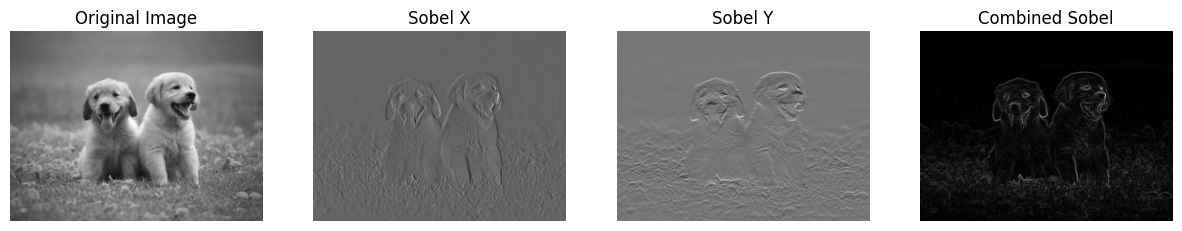

In [2]:
# Install libraries (only needed in Colab)
!pip install opencv-python matplotlib

import cv2
import numpy as np
from matplotlib import pyplot as plt
import urllib.request

# -------------------------------
# 1. Download sample image
# -------------------------------
# Changed the image URL to a dog image
image_url = "https://placedog.net/800/600?id=2"
# Add headers to mimic a browser request to avoid 403 Forbidden error
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'}
req = urllib.request.Request(image_url, headers=headers)

try:
    with urllib.request.urlopen(req) as response:
        with open("sample.jpg", "wb") as outfile:
            outfile.write(response.read())
except Exception as e:
    print(f"Error downloading image: {e}")
    exit()

# -------------------------------
# 2. Read image
# -------------------------------
img = cv2.imread("sample.jpg")

if img is None:
    print("Error loading image")
    exit()

# Convert image to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# -------------------------------
# 3. Apply Sobel Filter
# -------------------------------

# Sobel in X direction
sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=5)

# Sobel in Y direction
sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=5)

# Combined Sobel
sobel_combined = cv2.magnitude(sobel_x, sobel_y)

# -------------------------------
# 4. Display images
# -------------------------------
plt.figure(figsize=(15,5))

plt.subplot(1,4,1)
plt.title("Original Image")
plt.imshow(gray, cmap='gray')
plt.axis('off')

plt.subplot(1,4,2)
plt.title("Sobel X")
plt.imshow(sobel_x, cmap='gray')
plt.axis('off')

plt.subplot(1,4,3)
plt.title("Sobel Y")
plt.imshow(sobel_y, cmap='gray')
plt.axis('off')

plt.subplot(1,4,4)
plt.title("Combined Sobel")
plt.imshow(sobel_combined, cmap='gray')
plt.axis('off')

plt.show()